In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
# Cargar los datos
df = pd.read_csv("autos2.csv")
# Mostrar las primeras filas
df.head()
#Limpiar datos con "?"
df = df.replace("?", np.nan)

In [3]:
df = df.apply(pd.to_numeric, errors="ignore")
df = df.dropna()

/tmp/ipykernel_391/4465855.py:1: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors="ignore")


In [4]:
X = df[['horsepower', 'engine-size', 'city-mpg', 'wheel-base', 'bore']]
y = df['price']


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [7]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Error cuadrático medio (MSE): {mse:.2f}")
print(f"Coeficiente de determinación (R²): {r2:.2f}")

Error cuadrático medio (MSE): 7097649.23
Coeficiente de determinación (R²): 0.60


In [8]:
# Calcular el RMSE (más fácil de interpretar que el MSE)
rmse = np.sqrt(mse)
print(f"Raíz del Error cuadrático medio (RMSE): {rmse:.2f}")


Raíz del Error cuadrático medio (RMSE): 2664.14


In [9]:
coef_df = pd.DataFrame({
'Variable': X.columns,
'Coeficiente': model.coef_
})
print(coef_df)
print(f"Intersección (bias): {model.intercept_:.2f}")

      Variable  Coeficiente
0   horsepower    16.078760
1  engine-size   110.867146
2     city-mpg   -79.516132
3   wheel-base   370.445335
4         bore -1458.013016
Intersección (bias): -32788.74


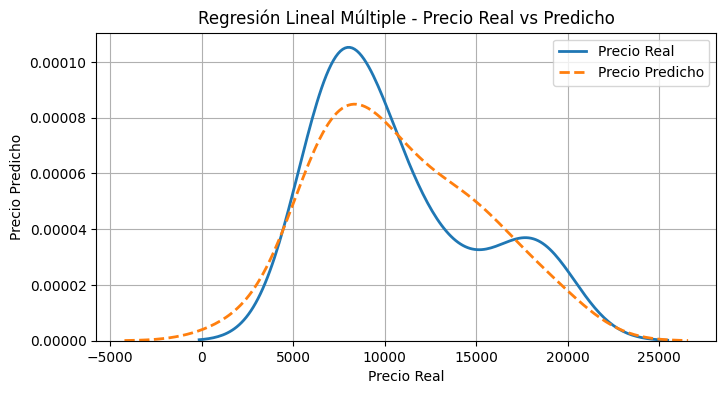

In [10]:
plt.figure(figsize=(8, 4))
sns.kdeplot(y_test, label='Precio Real', linewidth=2)
sns.kdeplot(y_pred, label='Precio Predicho', linewidth=2, linestyle='--')
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Regresión Lineal Múltiple - Precio Real vs Predicho")
plt.grid(True)
plt.legend()
plt.show()

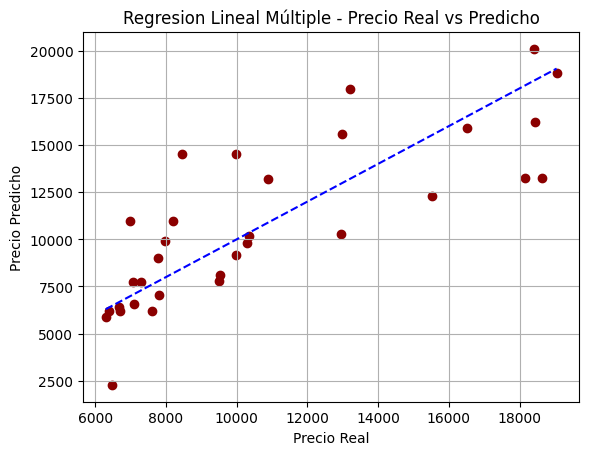

In [11]:
plt.scatter(y_test, y_pred, color='darkred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--') #
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Regresion Lineal Múltiple - Precio Real vs Predicho")
plt.grid(True)
plt.show()